In [2]:
%load_ext autoreload
%autoreload 2

In [78]:
import torch
from util import read_classes, read_anchors, draw_boxes, decode_predictions, apply_nms, denormalize
from model_torch import YOLOv2, train_model, wrap_yolo_loss, YoloV2GridTransform
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from dataset import VOCDataset, VOC_CLASSES
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
from PIL import Image


In [4]:
class_names = read_classes("model_data/coco_classes.txt")
print(class_names)
anchors = read_anchors("model_data/yolo_anchors.txt")
model_image_size = (608, 608) # Same as yolo_model input layer size
print(anchors)
num_classes = len(VOC_CLASSES)
num_anchors = len(anchors)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
anchors ['0.57273', ' 0.677385', ' 1.87446', ' 2.06253', ' 3.33843', ' 5.47434', ' 7.88282', ' 3.52778', ' 9.77052', ' 9.16828']
[[0.5

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [88]:
data_transforms = v2.Compose([
    v2.Resize((416,416)),
    # transforms.RandomRotation(degrees=15),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomAutocontrast(0.1),
    v2.ToImage(),                          # 1. Converts PIL Image to a Tensor image
    v2.ToDtype(torch.float32, scale=True), # 2. Converts to Float32 AND sca# les values to [0.0, 1.0]
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Always last
])


generators = torch.Generator().manual_seed(42)
batch_size = 64

dataset = VOCDataset(
    root="model_data/VOC2007",
    split_file=(
        "model_data/VOC2007/"
        "ImageSets/Main/trainval.txt"
    ),
    batch_size=batch_size,
    grid_shape=(13,13),
    anchors=anchors,
    transform=data_transforms,
)

# train_dataset = datasets.ImageFolder("model_data/VOC2007", transform=data_transforms)
train_dataset, val_dataset = random_split(dataset, [.8, .2], generator=generators)
val_dataset, test_dataset = random_split(val_dataset, [.5, .5], generator=generators)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

4009 501 501


In [15]:
image, target = train_dataset[0]
print(type(image), type(target))
print(image.size)
print(image.shape)

<class 'torchvision.tv_tensors._image.Image'> <class 'torch.Tensor'>
<built-in method size of Image object at 0x316abc370>
torch.Size([3, 416, 416])


In [9]:
learning_rate = 1e-3
weight_decay = 1e-4
epochs = 3 # use small epochs for transfer learning

# model = CNNModel(num_classes).to(device)
model = YOLOv2(num_anchors, num_classes).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs, # number of epochs
    eta_min=1e-6
)
loss_fn = wrap_yolo_loss(loss_weight=[1,1,1,1])


In [ ]:
epochs = 1
history = train_model(epochs,model, train_dataloader, val_dataloader, loss_fn, optimizer,scheduler, batch_size, device, num_classes)

train_loop-0 <class 'torch.Tensor'> <class 'torch.Tensor'>


KeyboardInterrupt: 

In [ ]:
weights_path = "save/yolov2.pth"
torch.save(model.state_dict(), weights_path)
print(f"Weights successfully saved to {weights_path}")

In [10]:
weights_path = "save/yolov2.pth"
state_dict = torch.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
print("Weights successfully loaded into model.")

Weights successfully loaded into model.


In [ ]:
print("Precision:", history["val_precision"])
print("Recall:", history["val_recall"])
print("F1:", history["val_f1"])

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15,5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Visualize prediction bounding box

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=375x500 at 0x30DF5E3F0>


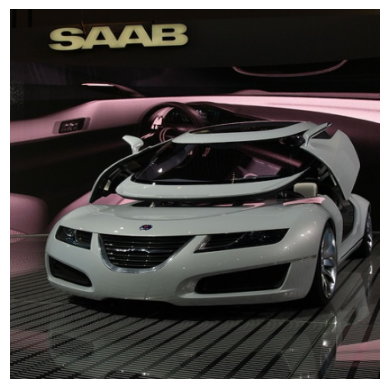

torch.Size([1, 13, 13, 5, 25])
torch.Size([13, 13, 5, 25])


In [95]:
# image, target = test_dataset[5]
# print(type(image), type(target))

image = Image.open("./model_data/VOC2007/JPEGImages/000020.jpg")
# print(image.size)
print(image)

image = data_transforms(image)
# image = denormalize(image)
# image = image.clamp(0, 1)

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")  
plt.show()

image = image.to(device)

# target = target.to(device)
image_1 = image.reshape(1, image.shape[0], image.shape[1], image.shape[2])

pred = model(image_1)
print(pred.shape)
pred = pred[0]
print(pred.shape)

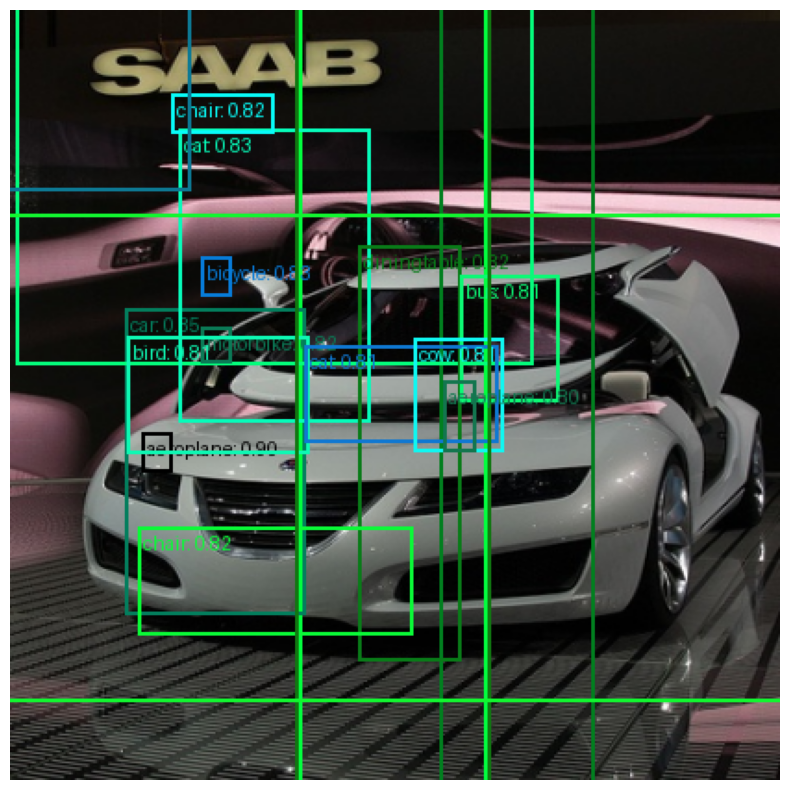

In [98]:
boxes, scores, labels = decode_predictions(
        pred,
        anchors,
        stride=32,
        conf_threshold=.8,
    )

boxes, scores, labels = apply_nms(
        boxes,
        scores,
        labels,
        iou_threshold=.6,
    )

label_strings = [
    f"{VOC_CLASSES[c]}: {s:.2f}"
    for c, s in zip(labels, scores)
]
# image_uint8 = (
#         image.cpu().clamp(0, 1) * 255
#     ).to(torch.uint8)

result = draw_bounding_boxes(
    image,
    boxes.cpu(),
    labels=label_strings,
    width=2,
)

plt.figure(figsize=(10, 10))
plt.imshow(to_pil_image(result))
plt.axis("off")
plt.show()